# Germline Whole Exome Sequencing (WES): Variant Annotation and Filtering

**Author:** Eman Koosehlar

**Version:** 1.4

**Last Updated:** July 2026

**Platform:** Google Colab

**Status:** Ready to run

# Learning Journey

This notebook is the second part of the **Germline Whole Exome Sequencing (WES) Analysis Series**.

In  [**Notebook 1: Germline WES Variant Calling**](https://github.com/namia47/WES_Analysis_Tutorial/notebooks/01_Germline_WES_Variant_Calling.ipynb), we generated a high-confidence germline VCF through quality control, read alignment, variant calling, and hard filtering. In this notebook, we take the next step by transforming those variants into biologically meaningful information through **variant annotation** and **initial prioritization**.

To provide both practical experience and a clinically relevant learning scenario, this notebook includes two complementary workflows:

* **Workflow A – Standard Annotation Pipeline:** Annotate and prioritize the filtered VCF generated in Notebook 1.
* **Workflow B – Simulated Clinical Case:** Apply the same workflow to a simulated patient containing a known pathogenic variant, preparing the data for clinical interpretation in the next notebook.

The outputs of both workflows are prioritized annotated VCF files containing candidate variants for downstream phenotype-driven analysis and clinical interpretation.

---

# Learning Objectives

By the end of this notebook, you will be able to:

* Explain the purpose of variant annotation in a germline WES workflow.
* Annotate variants using the **Ensembl Variant Effect Predictor (VEP)**.
* Interpret the biological information added during the annotation process.
* Apply a simple filtering strategy to prioritize candidate variants.
* Inspect and evaluate the resulting candidate variant list.
* Prepare annotated variants for phenotype-driven prioritization and ACMG/AMP-based interpretation in the next notebook.

---

# Overview

Starting from a filtered germline VCF file, this notebook demonstrates how to annotate variants with gene, transcript, protein consequence, population frequency, and other functional annotations using **Ensembl VEP**. The annotated variants are then filtered to retain a manageable set of candidate variants for downstream investigation.

The notebook is designed for **educational purposes** and emphasizes reproducibility, clarity, and understanding of each analysis step. While the workflow follows widely accepted bioinformatics best practices, it is intended as a learning resource and <span style= "color: #ff0000"> **should not be used for clinical diagnosis or medical decision-making**.</span>

By completing both workflows, you will generate prioritized annotated VCF files that are ready for phenotype-driven analysis and clinical interpretation in the subsequent notebooks of this series.


---

**Table of contents**<a id='toc0_'></a>    


- [Introduction](#toc1_)
- [Requirements and Environment Setup](#toc2_)

- [Input Datasets](#toc3_)
  - [Dataset A: Filtered VCF from Notebook 1](#toc3_1_)
  - [Dataset B: Simulated Clinical Case VCF](#toc3_2_)

- [Workflow A: Annotating a Filtered WES VCF](#toc4_)
  - [A.1. Load the Input VCF](#toc4_1_)
  - [A.2. Variant Annotation with VEP](#toc4_2_)
  - [A.3. Filter the Annotated Variants](#toc4_3_)
  - [A.4. Inspect the Candidate Variants](#toc4_4_)

- [Workflow B: Simulated Clinical Case Analysis](#toc5_)
  - [B.1. Load the Input VCF](#toc5_1_)
  - [B.2. Annotate the Clinical Case Variants](#toc5_2_)
  - [B.3. Filter the Annotated Variants](#toc5_3_)
  - [B.4. Inspect the Candidate Variants](#toc5_4_)
  
- [Summary](#toc6_)
- [References](#toc7_)


<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

---

## <a id='toc1_'></a>[Introduction](#toc0_)

After variant calling and quality filtering, a VCF file contains thousands of genomic variants represented only by their chromosomal positions and reference/alternate alleles. While this information identifies where sequence differences occur, it provides little insight into their potential biological or clinical significance.

Variant annotation is the process of enriching each variant with additional information, such as the affected gene, transcript, predicted functional consequence, protein change, population allele frequency, and known clinical evidence. This additional context enables researchers to move beyond genomic coordinates and begin evaluating which variants may be relevant to a phenotype or disease.

In this notebook, we use the **Ensembl Variant Effect Predictor (VEP)**, one of the most widely used annotation tools in human genomics. VEP compares variants against Ensembl databases and multiple external resources to predict their functional effects and add biologically meaningful annotations to the VCF file.

Following annotation, we apply a straightforward filtering strategy to reduce the number of candidate variants based on commonly used criteria, such as functional consequence, population frequency, and existing clinical annotations. These filtering steps are intended to prioritize variants for further investigation—they do **not** establish clinical pathogenicity.

The final output of this notebook is an annotated and filtered VCF file that serves as the starting point for variant prioritization and ACMG/AMP-based interpretation in the next notebooks of this series.


## <a id='toc2_'></a>[Requirements and Environment Setup](#toc0_)

- **Installing required tools**

In [ ]:
!apt-get update
!apt-get install -y cpanminus libssl-dev zlib1g-dev libncurses5-dev libbz2-dev liblzma-dev libperl-dev curl unzip


In [ ]:
!cpanm Module::Build
!cpanm Bio::Perl
!cpanm Set::IntervalTree
!cpanm Scalar::Util::Numeric
!cpanm JSON
!cpanm PerlIO::gzip


In [ ]:
!git clone https://github.com/Ensembl/ensembl-vep.git

In [ ]:
cd /content/ensembl-vep

In [ ]:
#!git checkout release/114

In [ ]:
!perl INSTALL.pl

- **Check the VEP tool**

In [ ]:
!perl /content/ensembl-vep/vep --help

- **Downloading Databases**

In [ ]:
cd /content/ensembl-vep

In [ ]:
cd /content/ensembl-vep/modules/Bio/EnsEMBL/VEP

In [ ]:
!wget https://raw.githubusercontent.com/Ensembl/VEP_plugins/release/93/Downstream.pm

In [ ]:
cd /content

*looking for available plugines and cache files needed for annotations*


In [ ]:
# Show Available plugins in vep

!perl /content/ensembl-vep/INSTALL.pl -a p -g list

In [ ]:
#!find -name 'Homo_sapiens.GRCh38.dna.toplevel.fa.gz'

In [ ]:
# list the available reference cache files for homo sapiens
!perl /content/ensembl-vep/INSTALL.pl -a f -s homo_sapiens -g list

In [ ]:
#!perl /content/ensembl-vep/INSTALL.pl -a p -g Downstream

In [ ]:
#!find / -name "Downstream.pm" 2>/dev/null

In [ ]:
#!find / -name "Homo_sapiens.GRCh38.dna.toplevel.fa.gz" 2>/dev/null

In [ ]:
cd /content/ensembl-vep

- **download the local annotation database for the GRCh38 reference genome**

It contains information such as:

Gene models
Transcripts
Protein sequences
Variant consequence definitions
Regulatory annotations
Other Ensembl annotation data

**Should check**

In [ ]:
perl INSTALL.pl -a cf -s homo_sapiens -y GRCh38

In [ ]:
# 24.9 Gb file volume ~16 minutes runtime
!curl -O ftp://ftp.ensembl.org/pub/release-114/variation/indexed_vep_cache/homo_sapiens_vep_114_GRCh38.tar.gz

In [ ]:
!gunzip /root/.vep/homo_sapiens/114_GRCh38/Homo_sapiens.GRCh38.dna.toplevel.fa.gz

In [ ]:
# Check the files in the directoy
ls /root/.vep/homo_sapiens/114_GRCh38/

- **Project Directories**

In [ ]:
!mkdir WES_Analysis
!mkdir WES_Analysis/Annotation WES_Analysis/VCF WES_Analysis/Prioritization

VCF = '/content/WES_Analysis/VCF'
Prioritization = '/content/WES_Analysis/Prioritization'
Annotation ='/content/WES_Analysis/Annotation'


To keep the workflow organized and reproducible, all files generated during the analysis are stored in dedicated project directories.

```text
WES_Analysis/
│
├── VCF/
│   └── Final VCF used for annotation
│
├── Annotation/
│   ├── Annotated VCF files
│   └── Annotation reports
│
├── Prioritization/
│   └── Filtered annotated VCF files ready for downstream interpretation
```

### Directory Description

* **VCF/** – Stores VCF files generated after variant calling and hard filtering.

* **Annotation/** – Stores VEP-annotated VCF files containing functional and clinical annotations.

* **Prioritization/** – Stores filtered annotated VCF files containing candidate variants for downstream analysis and ACMG interpretation.

## <a id='toc3_'></a>[Input Datasets](#toc0_)

### <a id='toc3_1_'></a>[Dataset A: Filtered VCF from the Germline WES Pipeline](#toc0_)

**Purpose**

This dataset is the output generated from the previous notebook, [**Germline WES Variant Calling**](https://github.com/namia47/WES_Analysis_Tutorial/notebooks/01_Germline_WES_Variant_Calling.ipynb). It contains high-confidence variants that have already passed quality control and hard filtering.

**Goal**

Use this dataset to continue the complete WES analysis workflow by performing:

- Variant annotation
- Population frequency annotation
- Functional consequence annotation
- Clinical annotation
- Preparation for variant prioritization

This option demonstrates how the notebooks are connected as part of a complete end-to-end WES analysis pipeline.

**Recommended for**

- Users following the notebook series from the beginning.
- Anyone who has already completed the Germline WES Variant Calling notebook.

### <a id='toc3_2_'></a>[Dataset B: Simulated Clinical Case VCF](#toc0_)


**Purpose**

This dataset is a pre-prepared VCF file that represents a simulated clinical Whole Exome Sequencing case. It allows users to begin the annotation workflow without performing the computationally intensive variant calling steps.

**Goal**

Use this dataset to learn variant annotation and interpretation independently of the previous notebook. This is particularly useful for educational purposes, workshops, or users interested only in downstream analysis.

**Recommended for**

- Beginners who want to focus on annotation.
- Workshop participants.
- Users with limited computational resources.
- Anyone interested in practicing annotation and variant interpretation without running the complete WES pipeline.

## <a id='toc4_'></a>[Workflow A: Annotating a Filtered WES VCF](#toc0_)

### <a id='toc4_1_'></a>[A.1. Load the Input VCF](#toc0_)

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

In [ ]:
!cp -r content/gdrive/MyDrive/WES_Analysis/VCF /content/WES_Analysis/

In [ ]:
!tail {VCF}/Exome_Norm_calls.filtered.PASS.vcf

VEP and reference databases use chromosome names without the `chr` prefix. To ensure compatibility between the VCF file and downstream tools or databases, the chromosome naming convention must match.


In [ ]:
# Remove the `chr` Prefix from Chromosome Names
!sed 's/^chr//' {VCF}/Exome_Norm_calls.filtered.PASS.vcf > {VCF}/Filtered_PASS_nochr.vcf

In [ ]:
# Checking again
!tail {VCF}/Filtered_PASS_nochr.vcf

In [ ]:
# !wget https://drive.google.com/file/d/1Ob0WeSjsfs89-ctPYOf9Am_oediVsE4Z/view?usp=sharing

### <a id='toc4_2_'></a>[A.2. Variant Annotation with VEP](#toc0_)

#### What is Variant Annotation?

Variant annotation is the process of adding biological and clinical information to each variant in a VCF file.

While variant calling identifies **where** genetic variants occur, annotation helps explain **what those variants might mean**.

#### Why is this step important?

A VCF file produced after variant calling contains only basic information about each variant, such as its genomic position and the reference and alternate alleles.

Annotation enriches each variant with additional information, including:

- The affected gene
- The predicted effect on the gene or protein
- Population allele frequencies
- Known clinical significance
- Previous reports in public databases

This information is essential for identifying variants that may be associated with disease.

#### Input

- `Filtered VCF file` containing high-confidence variants.

#### Output

- `Annotated VCF file` (or annotation report) containing biological and clinical information for each variant.


In [ ]:
# Running Annotation Step
!perl vep --cache --dir_cache /content/ensembl-vep --dir_plugins /root/.vep/Plugins/ --fork 8 --assembly=GRCh38 --offline --vcf --plugin Downstream --everything --terms SO --pick --coding_only --transcript_version -i {VCF}/Filtered_PASS_nochr.vcf -o {Annotaion}/Filtered_PASS_nochr.annotated.vcf --force_overwrite

*Key options of the command:* 
* --cache : Uses the local annotation cache for faster analysis.
* --offline : Runs without an internet connection.
* --assembly GRCh38 : Specifies the reference genome assembly.
* --everything : Adds a comprehensive set of annotation fields.
* --pick : Reports the single most relevant transcript annotation for each variant.
* --coding_only : Annotates only variants affecting coding regions.
* --vcf : Outputs the results in VCF format.
* -i : Input filtered VCF file.
* -o : Output annotated VCF file.

In [ ]:
# Checking the last 100 annotated variants 
!tail -100 {Annotaion}/Filtered_PASS_nochr.annotated.vcf

In [ ]:
# Optional command to save it in a tsv File rather than vcf
# !perl vep --dir_plugins /root/.vep/Plugins/ --database --fork 8 --assembly=GRCh38 --tab --plugin Downstream --everything --terms SO --pick --coding_only --transcript_version -i {VCF}/Filtered_PASS_nochr.vcf -o {Annotaion}/Filtered_PASS_nochr.annotated.tsv --force_overwrite


VEP, also will produce annotation report in a `html` file containing statistical informations and plots about variant types and classes.

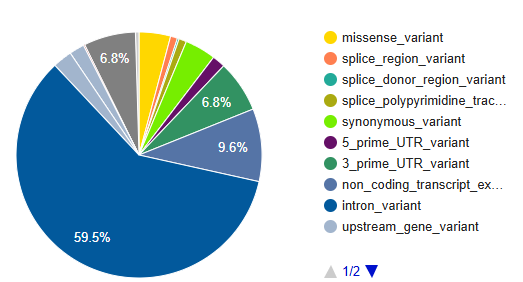


### <a id='toc4_3_'></a>[A.3. Filter the Annotated Variants](#toc0_)

#### What is this step?

After annotation, the VCF file contains detailed biological information for every variant. However, many of these variants are common in the general population or are predicted to have little or no functional effect.

This step filters the annotated variants to retain those that are more likely to be biologically or clinically relevant.

#### Why is this step important?

Filtering reduces the number of candidate variants, making downstream interpretation and prioritization more manageable.

In this example, variants are retained if they are:

* Rare in the general population.
* Predicted to have a **HIGH** or **MODERATE** functional impact.
* Predicted to be damaging by computational tools (for moderate-impact variants).

> **Note:** This filtering strategy is intended for research and educational purposes. It is not equivalent to ACMG variant classification.



In [ ]:
# Filtering Annotated Variants
!perl /content/ensembl-vep/filter_vep --format vcf -i {Annotaion}/Filtered_PASS_nochr.annotated.vcf -o {Prioritization}/Filtered_PASS_nochr.annotated.prioritized.vcf --filter "(MAX_AF < 0.001 or not MAX_AF) and ((IMPACT is HIGH) or (IMPACT is MODERATE and (SIFT match deleterious or PolyPhen match damaging)))" --force_overwrite



- **What does this command do?**

This command uses **filter_vep** to keep only variants that satisfy the specified filtering criteria.

#### Key filtering criteria

* `MAX_AF < 0.001`

  * Keeps variants with a maximum population allele frequency below **0.1%**, or variants with no reported population frequency.

* `IMPACT is HIGH`

  * Keeps variants predicted to have a severe effect on gene function.

* `IMPACT is MODERATE`

  * Keeps variants with a moderate predicted effect **only if** they are also predicted to be damaging.

* `SIFT match deleterious`

  * Retains variants predicted by SIFT to negatively affect protein function.

* `PolyPhen match damaging`

  * Retains variants predicted by PolyPhen to damage the protein.

#### Input

* `Annotated VCF file`

#### Output

* A `filtered annotated VCF file` containing a smaller set of potentially relevant variants for downstream prioritization and interpretation.

### <a id='toc4_4_'></a>[A.4. Inspect the Candidate Variants](#toc0_)

#### Purpose

After variant annotation and prioritization, it is good practice to inspect the final VCF file before proceeding to downstream interpretation.

This step allows us to:

* Verify that the filtering criteria were applied successfully.
* Determine how many candidate variants remain.
* Examine the annotation fields added by VEP.
* Ensure the output is ready for variant interpretation and ACMG classification.

#### View the VCF Header

The header describes the annotation fields and metadata contained in the VCF file.

#### Explanation

* `grep "^#"` selects only the header lines.
* `head -30` displays the first 30 lines.

This provides information about the annotation software, reference genome, and available annotation fields.


In [ ]:
!grep "^#" {Prioritization}/Filtered_PASS_nochr.annotated.prioritized.vcf | head -30

#### Count the Number of Candidate Variants


#### Explanation

* `grep -v "^#"` removes the header lines.
* `-c` counts the remaining variant records.

This gives the total number of prioritized variants.

In [ ]:
!grep -vc "^#" {Prioritization}/Filtered_PASS_nochr.annotated.prioritized.vcf

In [ ]:
#### Calculate how many variants were removed

before=$(grep -vc "^#" {Annotation}/Filtered_PASS_nochr.annotated.vcf)
after=$(grep -vc "^#" {Prioritization}/Filtered_PASS_nochr.annotated.prioritized.vcf)

!echo "Variants before prioritization : $before"
!echo "Variants after prioritization  : $after"
!echo "Variants removed               : $((before-after))"

#### View the First Few Variants


#### Explanation

* Removes the VCF header.
* Displays the first few prioritized variants.

This allows a quick inspection of the final output.

In [ ]:
!grep -v "^#" {Prioritization}/Filtered_PASS_nochr.annotated.prioritized.vcf | head

#### Search for Variants in a Specific Gene (Optional)



#### Explanation

Searches the annotated VCF for variants associated with a specific gene.

Replace `BRCA1` with any gene of interest.

In [ ]:
!grep "BRCA1" {Prioritization}/Filtered_PASS_nochr.annotated.prioritized.vcf

#### Inspect the Annotation Field

#### Explanation

* `cut -f8` extracts the INFO column.
* The INFO column contains the annotations added by VEP.

Reviewing this field helps confirm that the annotation was successfully added.

In [ ]:
!grep -v "^#" {Prioritization}/Filtered_PASS_nochr.annotated.prioritized.vcf | cut -f8 | head

## <a id='toc5_'></a>[Workflow B: Simulated Clinical Case Analysis](#toc0_)

In addition to using the filtered VCF generated in [**01_Germline_WES_Variant_Calling**](https://github.com/namia47/WES_Analysis_Tutorial/notebooks/01_Germline_WES_Variant_Calling.ipynb) notebook , this notebook also provides a simulated clinical case for educational purposes.

The simulated dataset is created by introducing a known pathogenic variant associated with a syndrome into the filtered VCF. This allows learners to practice variant annotation and prioritization using a realistic clinical scenario while avoiding patient privacy concerns.

The objective is **not** to identify the variant immediately, but to produce a prioritized annotated VCF that serves as the starting point for clinical interpretation in the next notebook.

By following this workflow, learners can experience how a pathogenic variant progresses through a complete WES analysis pipeline—from variant calling and annotation to phenotype-driven prioritization and clinical interpretation.


### <a id='toc5_1_'></a>[B.1. Load the Input VCF](#toc0_)

In [ ]:
!git clone https://github.com/namia47/WES_Analysis_Tutorial.git

In [ ]:
clinical_case_01_vcf = "/content/WES_Analysis_Tutorial/data/clinical_case_01.vcf"

### <a id='toc5_2_'></a>[B.2. Annotate the Clinical Case Variants](#toc0_)

In this step, we annotate the variants from **Clinical Case 1** using the same VEP workflow introduced in **Workflow A**.

Rather than explaining the annotation process again, this workflow focuses on applying the same methodology to a realistic clinical case. The annotation adds functional and biological information that will help identify variants with potential clinical relevance.

**Expected Output**

An annotated VCF file containing functional information for every variant in the simulated clinical case.


In [ ]:
# Running Annotation Step
!perl vep --cache --dir_cache /content/ensembl-vep --dir_plugins /root/.vep/Plugins/ --fork 8 --assembly=GRCh38 --offline --vcf --plugin Downstream --everything --terms SO --pick --coding_only --transcript_version -i {clinical_case_01_vcf} -o {Annotaion}/clinical_case_01.annotated.vcf --force_overwrite

In [ ]:
# Checking the last annotated variants 
!tail {Annotaion}/clinical_case_01.annotated.vcf 

### <a id='toc5_3_'></a>[B.3. Filter the Annotated Variants](#toc0_)

Next, we apply the same filtering strategy used in **Workflow A** to reduce the number of candidate variants.

The filtering criteria retain rare variants with a predicted functional impact while removing variants that are unlikely to contribute to the patient's phenotype.

The goal is not to identify the causal variant immediately, but to generate a manageable list of candidate variants for further investigation.

**Expected Output**

A prioritized annotated VCF file containing a small set of candidate variants that warrant further clinical evaluation.


In [ ]:
# Filtering Annotated Variants
!perl /content/ensembl-vep/filter_vep --format vcf -i {Annotaion}/clinical_case_01.annotated.vcf -o {Prioritization}/clinical_case_01.annotated.prioritized.vcf --filter "(MAX_AF < 0.001 or not MAX_AF) and ((IMPACT is HIGH) or (IMPACT is MODERATE and (SIFT match deleterious or PolyPhen match damaging)))" --force_overwrite

### <a id='toc5_4_'></a>[B.4. Inspect the Candidate Variants](#toc0_)

Next, we apply the same filtering strategy used in **Workflow A** to reduce the number of candidate variants.

The filtering criteria retain rare variants with a predicted functional impact while removing variants that are unlikely to contribute to the patient's phenotype.

The goal is not to identify the causal variant immediately, but to generate a manageable list of candidate variants for further investigation.

**Expected Output**

A prioritized annotated VCF file containing a small set of candidate variants that warrant further clinical evaluation.


In [ ]:
!grep "^#" {Prioritization}/clinical_case_01.annotated.prioritized.vcf | head -30

In [ ]:
!grep -v "^#" {Prioritization}/clinical_case_01.annotated.prioritized.vcf | head

> At this point, we have a list of candidate variants—but we still do not know which one explains the patient's phenotype. In the `next notebook`, we will combine genetic evidence with clinical information to identify the most likely disease-causing variant and evaluate it using the `ACMG/AMP` guidelines.

## <a id='toc6_'></a>[Summary](#toc0_)

In this notebook, we performed a complete variant annotation and prioritization workflow starting from a filtered germline Whole Exome Sequencing (WES) VCF file.

To provide both a practical analysis pipeline and a clinically relevant learning experience, the notebook includes **two complementary workflows**:

* **Workflow A:** Annotation and prioritization of a filtered VCF generated from the previous WES variant calling notebook.
* **Workflow B:** Annotation and prioritization of a simulated clinical case containing a known pathogenic variant, designed to prepare learners for clinical variant interpretation in the next notebook.

Across these workflows, the analysis included:

1. Preparing the project directory structure.
2. Loading a filtered VCF file generated from the previous WES variant calling workflow.
3. Annotating variants using Ensembl Variant Effect Predictor (VEP).
4. Adding functional and transcript-level annotations to each variant.
5. Filtering annotated variants based on population allele frequency and predicted functional impact.
6. Inspecting the final prioritized candidate variants to verify the filtering results.
7. Applying the same annotation and prioritization workflow to a simulated clinical case for downstream interpretation.

The final outputs of this notebook are prioritized annotated VCF files containing **candidate variants** that are ready for clinical investigation.

### What We Achieved

By the end of this notebook, the retained variants have been enriched with functional annotations and filtered to produce a manageable list of candidate variants.

For the simulated clinical case, the candidate list contains a known disease-causing variant embedded within a realistic analysis workflow. Rather than identifying the causal variant immediately, this notebook prepares the data required for phenotype-driven analysis and clinical interpretation.

These candidate variants are now ready for further investigation using additional evidence such as:

* Patient phenotype
* Gene–disease associations
* Inheritance pattern
* Published literature
* ACMG/AMP variant interpretation guidelines

### Next Step

This notebook focuses on variant annotation and initial prioritization.

In the next notebook, we will investigate the candidate variants generated from the simulated clinical case by integrating genetic evidence with the patient's phenotype, inheritance information, and gene–disease knowledge. We will also introduce phenotype-driven prioritization using Exomiser and apply selected ACMG/AMP criteria to evaluate the evidence supporting variant pathogenicity.

> **Important:** Variant prioritization is not equivalent to clinical interpretation. Prioritization identifies variants that warrant further investigation, whereas clinical interpretation requires a comprehensive evaluation of genetic, phenotypic, population, functional, and literature-based evidence before assigning an ACMG/AMP classification.


## <a id='toc7_'></a>[References](#toc0_)

- McLaren W, Gil L, Hunt SE, et al. The Ensembl Variant Effect Predictor. Genome Biol. 2016;17(1):122. Published 2016 Jun 6. doi:10.1186/s13059-016-0974-4

- Vaser R, Adusumalli S, Leng SN, Sikic M, Ng PC. SIFT missense predictions for genomes. Nat Protoc. 2016;11(1):1-9. doi:10.1038/nprot.2015.123 

- Adzhubei I, Jordan DM, Sunyaev SR. Predicting functional effect of human missense mutations using PolyPhen-2. Curr Protoc Hum Genet. 2013;Chapter 7:Unit7.20. doi:10.1002/0471142905.hg0720s76

- Gudmundsson S, Singer-Berk M, Watts NA, et al. Variant interpretation using population databases: Lessons from gnomAD. Hum Mutat. 2022;43(8):1012-1030. doi:10.1002/humu.24309 

- Richards S, Aziz N, Bale S, et al. Standards and guidelines for the interpretation of sequence variants: a joint consensus recommendation of the American College of Medical Genetics and Genomics and the Association for Molecular Pathology. Genet Med. 2015;17(5):405-424. doi:10.1038/gim.2015.30

- VEP Documentation: https://www.ensembl.org/info/docs/tools/vep/online/VEP_web_documentation.pdf

---